# Zero-Knowledge Proofs: Proving Without Revealing

RSA (the previous lesson) lets you **hide data**: scramble a message so only the key-holder can read it. But cryptography has a subtler need. Sometimes you must prove a *fact* about a secret without exposing the secret itself.

- Prove you know the password without typing it.
- Prove you are over 18 without showing your date of birth.
- Prove a transaction is valid without revealing the amounts (this is the engine behind zk-SNARKs and private blockchains).

A **zero-knowledge proof** is an interactive protocol between a **Prover**, who claims a statement is true, and a **Verifier**, who is skeptical. By the end the Verifier is convinced the statement is true and has learned *nothing else* - not even enough to convince anyone else.

There is one more reason this lesson sits between RSA and Shor. RSA's security rests on factoring being hard, an assumption Shor's quantum algorithm attacks directly. The proofs in this notebook rest on something different: **probability**. Their soundness is a counting argument, not a hardness assumption, so the core guarantee survives even a quantum adversary.


## 1. The Three Properties

Every zero-knowledge proof must satisfy three conditions. Keep them in view; the whole notebook is about earning them.

- **Completeness.** If the statement is true and the Prover is honest, the Verifier always accepts.
- **Soundness.** If the statement is false, a cheating Prover is caught with high probability. We will make "high" precise: each challenge is a coin flip the cheat can only dodge with probability at most one half, so after `k` independent challenges the chance of fooling the Verifier is at most `(1/2)^k`.
- **Zero-knowledge.** The Verifier learns nothing beyond "the statement is true." Anything the Verifier sees could have been produced without the secret.

The trick that delivers all three is **interaction plus randomness**: the Verifier throws an unpredictable challenge each round, and a Prover who lacks the secret cannot prepare for every possible challenge at once.


## 2. The Ali Baba Cave

The classic intuition (Quisquater and Guillou, 1989). A ring-shaped cave forks into two passages, **A** and **B**, that meet at a **magic door** at the back. The door only opens for someone who knows the secret word.

Peggy (the Prover) claims she knows the word. Victor (the Verifier) wants proof, but Peggy refuses to say the word out loud. They run this protocol:

1. Victor waits outside. Peggy walks in and takes passage **A** or **B** out of his sight.
2. Victor steps to the fork and shouts the side he wants her to **come out of** - a fresh coin flip each time.
3. If Peggy knows the word she can open the door and emerge from either side. If she does not, she can only return the way she came.

One round proves little: a cheat who happens to be on the demanded side walks out and looks legitimate. The power comes from **repetition**.


**Imports and setup.** Arrays, plotting, animation, and a seeded random generator so runs are reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Arc, Rectangle
from IPython.display import HTML

rng = np.random.default_rng(7)

A, B = 0, 1
SIDE = {A: "A", B: "B"}


## 3. One Round of the Cave

A round has two random choices: which side Peggy **entered**, and which side Victor **challenges** her to exit.

- An honest Prover (knows the word) opens the door and always exits the demanded side, so she passes every round.
- A cheating Prover can only leave the way she came, so she passes a round **only if she happened to enter the side Victor demands** - probability one half.


**Round and protocol.** Victor rejects the moment a round fails. `predictable` will be used later to break the protocol on purpose.


In [2]:
def cave_round(knows_secret: bool, rng, predictable=None) -> dict:
    # A cheat facing a predictable Verifier pre-positions on the side it knows will be asked.
    if predictable is None:
        challenge = int(rng.integers(2))
        entered = int(rng.integers(2))
    else:
        challenge = int(predictable)
        entered = int(predictable)
    passed = True if knows_secret else (entered == challenge)
    return {"entered": entered, "challenge": challenge, "passed": bool(passed)}


def run_cave(knows_secret: bool, rounds: int, rng, predictable=None):
    history = []
    for _ in range(rounds):
        step = cave_round(knows_secret, rng, predictable)
        history.append(step)
        if not step["passed"]:
            return False, history  # Victor rejects on the first failure
    return True, history


demo_rng = np.random.default_rng(17)
accepted, history = run_cave(False, 5, demo_rng)
for i, step in enumerate(history, 1):
    print(f"round {i}: entered {SIDE[step['entered']]}, asked {SIDE[step['challenge']]}, "
          f"{'passed' if step['passed'] else 'CAUGHT'}")
print("cheat accepted overall:", accepted, "(lucky twice, then a fresh challenge exposed it)")


round 1: entered B, asked B, passed
round 2: entered A, asked A, passed
round 3: entered B, asked A, CAUGHT
cheat accepted overall: False (lucky twice, then a fresh challenge exposed it)


## 4. Completeness and Soundness, Measured

Run the protocol many times and count acceptances. An honest Prover should be accepted every single time. A cheat should be accepted at a rate that halves with every extra round.


**Acceptance rate.** Fraction of full protocols the Verifier accepts, over many independent runs.


In [3]:
def acceptance_rate(knows_secret: bool, rounds: int, trials: int, rng, predictable=None) -> float:
    accepts = sum(run_cave(knows_secret, rounds, rng, predictable)[0] for _ in range(trials))
    return accepts / trials


TRIALS = 40_000
print("COMPLETENESS")
print(f"  honest Prover, 20 rounds: accepted {acceptance_rate(True, 20, 5000, rng):.3f} of the time (expect 1.000)")
print("\nSOUNDNESS  (cheating Prover)")
print(f"  {'rounds':>6} | {'measured accept':>15} | {'(1/2)^k':>10}")
for k in (1, 2, 5, 10, 20):
    measured = acceptance_rate(False, k, TRIALS, rng)
    print(f"  {k:>6} | {measured:>15.6f} | {0.5 ** k:>10.6f}")


COMPLETENESS


  honest Prover, 20 rounds: accepted 1.000 of the time (expect 1.000)

SOUNDNESS  (cheating Prover)
  rounds | measured accept |    (1/2)^k
       1 |        0.495500 |   0.500000


       2 |        0.250025 |   0.250000


       5 |        0.032000 |   0.031250


      10 |        0.000725 |   0.000977


      20 |        0.000000 |   0.000001


The cheat's acceptance probability is `(1/2)^k`. That is the soundness guarantee, and it is just counting, not a hardness assumption.

How many rounds buy "less than one in a million"?


**Choosing k.** Find the smallest number of rounds that drives the cheat's success below a target.


In [4]:
def rounds_for_confidence(target: float) -> int:
    k = 1
    while 0.5 ** k >= target:
        k += 1
    return k


for target in (1e-3, 1e-6, 1e-9):
    k = rounds_for_confidence(target)
    print(f"to push a cheat below {target:.0e}: {k} rounds  (actual {0.5 ** k:.2e})")


to push a cheat below 1e-03: 10 rounds  (actual 9.77e-04)
to push a cheat below 1e-06: 20 rounds  (actual 9.54e-07)
to push a cheat below 1e-09: 30 rounds  (actual 9.31e-10)


**Soundness curve.** The cheat's surviving probability falls geometrically; 20 rounds clears one in a million.


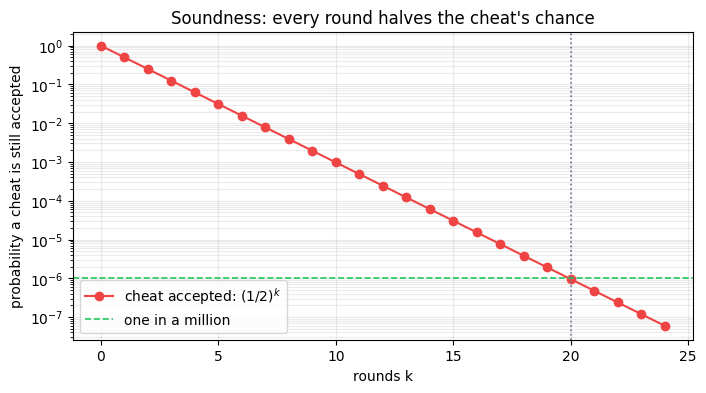

In [5]:
ks = np.arange(0, 25)
survive = 0.5 ** ks

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(ks, survive, marker="o", color="#ef4444", label="cheat accepted: $(1/2)^k$")
ax.axhline(1e-6, color="#22c55e", ls="--", lw=1.2, label="one in a million")
ax.axvline(20, color="#64748b", ls=":", lw=1.2)
ax.set_xlabel("rounds k")
ax.set_ylabel("probability a cheat is still accepted")
ax.set_title("Soundness: every round halves the cheat's chance")
ax.legend()
ax.grid(alpha=0.25, which="both")
plt.show()


## 5. Watching the Doubt Collapse

The animation below replays an honest Prover. Each round she emerges from whichever side Victor demands - she always can. The right panel tracks the only thing that matters to Victor: **the probability that a faker could have produced this same run of successes**, which is `(1/2)^k`. Watch his remaining doubt fall through the floor.


**Cave schematic.** A ring with two passages and a locked door; the green marker is the Prover emerging from the demanded side.


In [6]:
def draw_cave(ax, challenge: int, round_idx: int):
    ax.plot([-1, -1], [0, 3], color="#475569", lw=6)
    ax.plot([1, 1], [0, 3], color="#475569", lw=6)
    ax.add_patch(Arc((0, 3), 2, 2, theta1=0, theta2=180, color="#475569", lw=6))
    ax.add_patch(Rectangle((-0.18, 2.82), 0.36, 0.36, color="#b45309"))
    ax.text(0, 3.5, "locked door\n(opens only with the secret)", ha="center", va="bottom", fontsize=8)
    ax.text(-1, -0.4, "A", ha="center", fontsize=13, fontweight="bold")
    ax.text(1, -0.4, "B", ha="center", fontsize=13, fontweight="bold")
    ax.text(0, -0.8, "entrance", ha="center", fontsize=9, color="#64748b")
    x = -1 if challenge == A else 1
    ax.scatter([x], [0.18], s=200, color="#22c55e", zorder=5, edgecolors="black")
    ax.set_title(f"Round {round_idx}: Victor shouts \u201ccome out {SIDE[challenge]}\u201d  \u2192  Peggy emerges \u2713",
                 fontsize=10)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 4.3)
    ax.set_aspect("equal")
    ax.axis("off")


**Animation.** Replay the honest run while the cheat-survival probability collapses.


In [7]:
def animate_cave(rounds: int = 12, seed: int = 1) -> HTML:
    local = np.random.default_rng(seed)
    challenges = [int(local.integers(2)) for _ in range(rounds)]
    ks = np.arange(0, rounds + 1)
    survive = 0.5 ** ks

    fig, (axc, axs) = plt.subplots(1, 2, figsize=(11, 4.8))

    def update(frame: int):
        axc.clear()
        axs.clear()
        draw_cave(axc, challenges[frame], frame + 1)

        axs.semilogy(ks, survive, color="#cbd5e1", lw=2, zorder=1)
        axs.semilogy(ks[: frame + 2], survive[: frame + 2], color="#ef4444", lw=2.5, zorder=2)
        axs.scatter([frame + 1], [survive[frame + 1]], s=70, color="#ef4444", zorder=3, edgecolors="black")
        axs.axhline(1e-6, color="#22c55e", ls="--", lw=1.2)
        axs.set_xlim(0, rounds)
        axs.set_ylim(0.5 ** rounds / 4, 1.5)
        axs.set_xlabel("rounds passed")
        axs.set_ylabel("chance a faker could do this")
        axs.set_title(f"After {frame + 1} rounds: a cheat's odds = {survive[frame + 1]:.2e}", fontsize=10)
        axs.grid(alpha=0.25, which="both")

    anim = animation.FuncAnimation(fig, update, frames=rounds, interval=650)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_cave(rounds=12, seed=1)


## 6. Failure Mode: Predictable Challenges

Soundness depends entirely on the Verifier's challenge being **unpredictable**. Suppose Victor gets lazy and always shouts the same side - or Peggy learns his pattern in advance. Now a cheat who does **not** know the secret simply walks down that side every time and emerges on cue, passing every round.

The protocol still "accepts," but it now proves nothing. Independent randomness is not a detail; it is the whole engine of soundness.


**Break it.** Re-run the cheat against a predictable Verifier and compare with the random Verifier.


In [8]:
random_cheat = acceptance_rate(False, 20, 5000, rng)
predictable_cheat = acceptance_rate(False, 20, 5000, rng, predictable=B)

print(f"cheat vs RANDOM verifier, 20 rounds:      accepted {random_cheat:.4f}  (sound: ~1e-6)")
print(f"cheat vs PREDICTABLE verifier, 20 rounds: accepted {predictable_cheat:.4f}  (broken: proves nothing)")


cheat vs RANDOM verifier, 20 rounds:      accepted 0.0000  (sound: ~1e-6)
cheat vs PREDICTABLE verifier, 20 rounds: accepted 1.0000  (broken: proves nothing)


## 7. A Real Protocol: Graph 3-Coloring

The cave is intuition. Here is a zero-knowledge proof for a genuinely useful statement, and a template for *any* statement in NP.

A proper **3-coloring** of a graph assigns one of three colors to each vertex so that no edge joins two vertices of the same color. Deciding whether a graph is 3-colorable is NP-complete - hard in general. Suppose Peggy has found a valid coloring (her secret **witness**) and wants to prove the graph is colorable **without revealing the coloring**.

The protocol, one round:

1. Peggy randomly **permutes** her three colors (red/green/blue could become blue/red/green), then **commits** to every vertex's color in a sealed envelope - hidden from Victor.
2. Victor picks one **random edge** and asks Peggy to open just its two endpoints.
3. Peggy reveals those two colors. Victor accepts the round if they **differ**.

Completeness: a valid coloring has differing colors on every edge, so an honest Peggy always passes. Soundness: if Peggy's coloring is invalid it has at least one same-colored edge, which Victor hits with probability at least `1/|E|` each round. Zero-knowledge: the fresh permutation each round means the two revealed colors are just "some two different colors," carrying no information about the real coloring.


**A 3-colorable graph.** The triangular prism: an inner and outer triangle joined by spokes. `VALID` is a proper coloring; `CHEAT` plants one bad edge.


In [9]:
EDGES = [(0, 1), (1, 2), (2, 0),   # inner triangle
         (3, 4), (4, 5), (5, 3),   # outer triangle
         (0, 3), (1, 4), (2, 5)]   # spokes
POS = {0: (-0.6, -0.35), 1: (0.6, -0.35), 2: (0.0, 0.7),
       3: (-1.7, -1.05), 4: (1.7, -1.05), 5: (0.0, 1.95)}
PALETTE = ["#ef4444", "#3b82f6", "#22c55e"]

VALID = [0, 1, 2, 1, 2, 0]   # a proper 3-coloring
CHEAT = [0, 1, 2, 2, 2, 0]   # one monochromatic edge: (3, 4)


def proper(coloring) -> bool:
    return all(coloring[u] != coloring[v] for u, v in EDGES)


def bad_edges(coloring):
    return [(u, v) for u, v in EDGES if coloring[u] == coloring[v]]


print("VALID is a proper coloring:", proper(VALID))
print("CHEAT bad edges:", bad_edges(CHEAT), "->", len(bad_edges(CHEAT)), "of", len(EDGES))


VALID is a proper coloring: True
CHEAT bad edges: [(3, 4)] -> 1 of 9


**One zero-knowledge round.** Permute the colors, then reveal only the challenged edge.


In [10]:
def coloring_round(coloring, rng) -> dict:
    perm = rng.permutation(3)
    masked = [int(perm[c]) for c in coloring]      # rename colors; edge agreements unchanged
    u, v = EDGES[int(rng.integers(len(EDGES)))]    # Victor's random edge
    return {"edge": (u, v), "revealed": (masked[u], masked[v]),
            "passed": masked[u] != masked[v], "masked": masked}


def run_coloring(coloring, rounds: int, rng):
    history = []
    for _ in range(rounds):
        step = coloring_round(coloring, rng)
        history.append(step)
        if not step["passed"]:
            return False, history
    return True, history


**Draw a round.** Hidden vertices are grey; only the challenged edge's endpoints reveal their (permuted) colors.


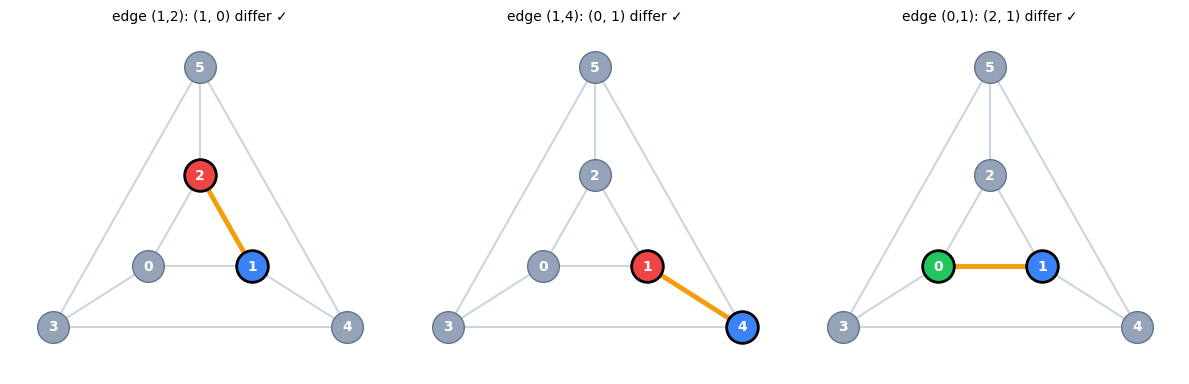

In [11]:
def draw_graph_round(ax, step, title):
    challenged = step["edge"]
    for u, v in EDGES:
        hot = {u, v} == set(challenged)
        ax.plot([POS[u][0], POS[v][0]], [POS[u][1], POS[v][1]],
                color="#f59e0b" if hot else "#cbd5e1", lw=3.5 if hot else 1.5, zorder=1)
    for node, (x, y) in POS.items():
        if node in challenged:
            color = PALETTE[step["masked"][node]]
            edgecolor, lw = "black", 2.0
        else:
            color, edgecolor, lw = "#94a3b8", "#64748b", 1.0  # committed, still sealed
        ax.scatter([x], [y], s=520, color=color, edgecolors=edgecolor, linewidths=lw, zorder=2)
        ax.text(x, y, str(node), ha="center", va="center", color="white", fontweight="bold", zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-1.6, 2.4)
    ax.set_aspect("equal")
    ax.axis("off")


demo_rng = np.random.default_rng(3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax in axes:
    step = coloring_round(VALID, demo_rng)
    u, v = step["edge"]
    verdict = "differ \u2713" if step["passed"] else "same \u2717"
    draw_graph_round(ax, step, f"edge ({u},{v}): {step['revealed']} {verdict}")
plt.tight_layout()
plt.show()


**Completeness and soundness.** The honest Prover always passes; the cheat's single bad edge is eventually hit.


In [12]:
E = len(EDGES)
b = len(bad_edges(CHEAT))

honest_graph = sum(run_coloring(VALID, 50, rng)[0] for _ in range(3000)) / 3000
print(f"COMPLETENESS  honest Prover, 50 rounds: {honest_graph:.3f}  (expect 1.000)")
print("\nSOUNDNESS  cheating Prover (1 bad edge of 9, so caught with prob 1/9 each round)")
print(f"  {'rounds':>6} | {'measured accept':>15} | {'(1 - b/E)^k':>12}")
for k in (1, 9, 25, 50):
    measured = sum(run_coloring(CHEAT, k, rng)[0] for _ in range(20000)) / 20000
    print(f"  {k:>6} | {measured:>15.6f} | {(1 - b / E) ** k:>12.6f}")


COMPLETENESS  honest Prover, 50 rounds: 1.000  (expect 1.000)

SOUNDNESS  cheating Prover (1 bad edge of 9, so caught with prob 1/9 each round)
  rounds | measured accept |  (1 - b/E)^k
       1 |        0.889100 |     0.888889


       9 |        0.354500 |     0.346439


      25 |        0.053050 |     0.052624


      50 |        0.003750 |     0.002769


The cave halved the cheat's odds each round; here each round multiplies them by `1 - 1/|E|`. Slower, but the same idea: enough independent challenges drive a false claim's survival to zero. This is exactly the one-sided-error structure you saw in Bloom filters (Module 4) and the sampling confidence of Monte Carlo Tree Search (Module 5).


**Zero-knowledge check.** Over many rounds the revealed color pairs are uniform over all six distinct ordered pairs - they betray nothing about the actual coloring.


In [13]:
from collections import Counter

pairs = Counter(coloring_round(VALID, rng)["revealed"] for _ in range(60000))
print("revealed (color, color) pair frequencies (each should be ~1/6 = 0.167):")
for pair, count in sorted(pairs.items()):
    print(f"   {pair}: {count / 60000:.3f}")
print("\nVictor sees only 'two different colors' - never which real colors, so he learns nothing reusable.")


revealed (color, color) pair frequencies (each should be ~1/6 = 0.167):
   (0, 1): 0.168
   (0, 2): 0.166
   (1, 0): 0.167
   (1, 2): 0.165
   (2, 0): 0.168
   (2, 1): 0.167

Victor sees only 'two different colors' - never which real colors, so he learns nothing reusable.


## 8. Why This Generalizes

Graph 3-coloring is **NP-complete**, so *any* statement whose truth can be checked quickly - "I know a password hash preimage," "this transaction balances," "I am a citizen" - can be rewritten as a graph coloring and proved in zero knowledge. That universality is why ZKPs underpin modern privacy technology.

- **zk-SNARKs** make the proof **non-interactive** (one short message, no back-and-forth) and **succinct** (tiny and fast to check), powering private cryptocurrencies and blockchain scaling.
- Because soundness here is a probability bound rather than a hardness assumption like factoring, the core argument is **not broken by quantum computers** - a pointed contrast with RSA, which Shor's algorithm dismantles later in this module.

## 9. Mini-Challenge

Try one:

1. Change `CHEAT` to plant two or three bad edges. How does the measured soundness curve shift, and does it match `(1 - b/|E|)^k`?
2. Build a larger 3-colorable graph (more edges) with a single bad edge. Does a bigger `|E|` make a cheat *easier* or *harder* to catch per round, and why?
3. Make the cave Verifier issue challenges from a fixed repeating pattern (`A, B, A, B, ...`). Write a cheat that beats it, then confirm a uniformly random Verifier restores soundness.
4. Combine challenges into batches: how many cave rounds equal the soundness of one graph round on the prism, and vice versa?
5. Sketch (in markdown) how you would turn the interactive graph protocol into a non-interactive one using a hash of the commitments as the "challenge" (the Fiat-Shamir heuristic).


**Invariant check.** Completeness must be exact, and the color permutation must never change whether an edge's endpoints agree.


In [14]:
check_rng = np.random.default_rng(99)
honest_always = all(coloring_round(VALID, check_rng)["passed"] for _ in range(5000))
print("honest Prover passes every sampled round (completeness):", honest_always)

# A permutation renames colors but preserves the equal/unequal relation on every edge.
perm = check_rng.permutation(3)
masked = [int(perm[c]) for c in CHEAT]
same_bad_edges = bad_edges(CHEAT) == [(u, v) for u, v in EDGES if masked[u] == masked[v]]
print("permutation preserves which edges are monochromatic (soundness intact):", same_bad_edges)


honest Prover passes every sampled round (completeness): True
permutation preserves which edges are monochromatic (soundness intact): True


## Visual Trace + Rigor Studio

**Problem frame.** Convince a skeptical Verifier that a statement is true - you know the cave's secret word, or the graph has a proper 3-coloring - while revealing nothing the Verifier could reuse.

**Interactive animation target.** Animate the cave round by round (Prover emerging from the demanded side) beside a log-scale panel showing the cheat-survival probability `(1/2)^k` collapsing, with controls for the number of rounds and the random seed.

**Correctness handle.** Completeness: an honest Prover satisfies every possible challenge, so acceptance is certain. Soundness: a false claim fails each independent challenge with probability at least `p` (one half in the cave, `1/|E|` in the coloring graph), so acceptance after `k` rounds is at most `(1 - p)^k`. Zero-knowledge: each round's transcript is a fresh re-randomization, so it could have been simulated without the secret.

**Complexity handle.** `k` rounds, `O(1)` work per cave round and `O(|V| + |E|)` per coloring round; soundness error shrinks as `(1 - p)^k`, so the round count grows only logarithmically in the confidence target.

**Failure mode to test.** Make the Verifier's challenge predictable (fixed side, or a known pattern). A cheat pre-positions for the known challenge and is accepted every round, so the protocol proves nothing. Independent per-round randomness is what soundness rests on.

**Studio task.** Find the smallest `k` that drives a cave cheat below one in a million (expect 20), then plant a second bad edge in `CHEAT` and find how many graph rounds reach the same confidence.

**Transfer.** The soundness argument is the one-sided error of Bloom filters (Module 4) and the sampling confidence of Monte Carlo Tree Search (Module 5): repeated independent checks crush the chance of a wrong conclusion. Unlike RSA, this guarantee is probabilistic, not a factoring assumption, so Shor's algorithm (later in this module) does not touch it.

## Sources and Further Reading

- Shafi Goldwasser, Silvio Micali, and Charles Rackoff, [The Knowledge Complexity of Interactive Proof Systems](https://doi.org/10.1137/0218012), *SIAM Journal on Computing* 18(1), 186-208 (1989) - the foundational paper.
- Jean-Jacques Quisquater et al., [How to Explain Zero-Knowledge Protocols to Your Children](https://link.springer.com/chapter/10.1007/0-387-34805-0_60), CRYPTO 1989 - the Ali Baba cave.
- Oded Goldreich, Silvio Micali, and Avi Wigderson, [Proofs that Yield Nothing But Their Validity](https://doi.org/10.1145/116825.116852), *JACM* 38(3), 690-728 (1991) - the graph 3-coloring protocol for all of NP.
- [Zcash: What are zk-SNARKs?](https://z.cash/learn/what-are-zk-snarks/) - non-interactive, succinct proofs in practice.

This is a compact teaching version. Real systems also need binding, hiding commitments, careful soundness amplification, and (for zk-SNARKs) a trusted setup or transparent alternative.
